In [1]:
import gymnasium as gym
import numpy as np
import torch
from models import Actor
import os
import matplotlib.pyplot as plt


PATH = "checkpoints/Humanoid-v5/"
ENV = "Humanoid-v5"

In [2]:
# load actor and enviornment
def load(name:str):
    env = gym.make(ENV, render_mode="human")
    sDim, aDim = env.observation_space.shape[0], env.action_space.shape[0]
    agent = Actor(sDim, aDim)
    agent.load_state_dict(torch.load(os.path.join(PATH, name)))
    return env, agent

# simulate
def run(env, agent, episodes, render):
    for episode in range(episodes):
        state, info = env.reset()
        rewards = 0
        done = False
        while not done:
            action, _ = agent.forward(torch.from_numpy(state).float())
            state, r, terminated, truncated, info = env.step(action.detach().numpy())
            done = terminated or truncated
            rewards += r
            if render is True: 
                env.render()
        print(f"Episode {episode+1}; Rewards: {rewards:.2f}")

In [3]:
env, agent = load("actor.pth")

run(env, agent, 3, True)

env.close()

Episode 1; Rewards: 3684.29
Episode 2; Rewards: 3858.44
Episode 3; Rewards: 3637.01


In [ ]:
# test all models save during training

folder = sorted([f for f in os.listdir(PATH) if "actor_" in f])
for f in folder:
        print(f"Model: {f}")
        env, agent = load(f)
        run(env, agent, 1, True)
        env.close()

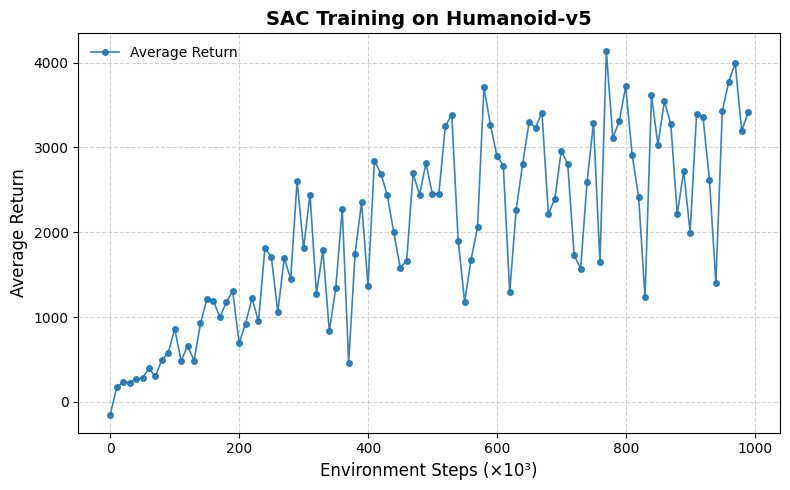

In [11]:
# plot rewards

rewards = list(np.load(PATH+"rewards.npy"))
steps = 10 * np.arange(len(rewards))

plt.figure(figsize=(8,5))
plt.plot(
    steps, rewards,
    marker="o", markersize=4,
    linestyle="-", linewidth=1.2,
    alpha=0.9, label="Average Return"
)

# Labels and title
plt.xlabel("Environment Steps (×10³)", fontsize=12)
plt.ylabel("Average Return", fontsize=12)
plt.title("SAC Training on Humanoid-v5", fontsize=14, weight="bold")

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(frameon=False)
plt.tight_layout()

plt.show()

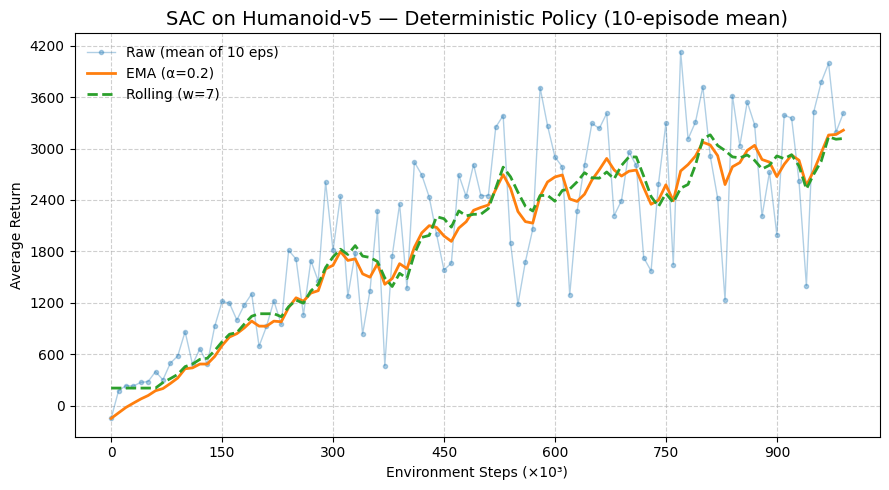

In [13]:
from matplotlib.ticker import MaxNLocator

# --- Load your data ---
rewards = np.load(PATH + "rewards.npy")            # shape [T], each point = mean over 10 eval eps
step_interval_k = 10                                # eval every 10k env steps
steps_k = np.arange(len(rewards)) * step_interval_k

# --- Smoothing helpers ---
def ema(x, alpha=0.2):
    y = np.empty_like(x, dtype=float)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha * x[i] + (1 - alpha) * y[i-1]
    return y

def rolling(x, w=7):
    if w <= 1 or w > len(x): return x.astype(float)
    c = np.cumsum(np.insert(x, 0, 0.0))
    y = (c[w:] - c[:-w]) / float(w)
    # left-pad to original length with the first smoothed value
    pad = np.full(w-1, y[0])
    return np.concatenate([pad, y])

ema_curve = ema(rewards, alpha=0.2)   # try 0.1–0.3
roll_curve = rolling(rewards, w=7)    # try 5–11

# --- Plot ---
plt.figure(figsize=(9,5))
plt.plot(steps_k, rewards, marker="o", markersize=3, linewidth=1, alpha=0.35, label="Raw (mean of 10 eps)")
plt.plot(steps_k, ema_curve, linewidth=2, label="EMA (α=0.2)")
plt.plot(steps_k, roll_curve, linewidth=2, linestyle="--", label="Rolling (w=7)")

plt.title("SAC on Humanoid-v5 — Deterministic Policy (10-episode mean)", fontsize=14)
plt.xlabel("Environment Steps (×10³)")
plt.ylabel("Average Return")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(frameon=False)

ax = plt.gca()
ax.xaxis.set_major_locator(MaxNLocator(nbins=8, integer=True))
ax.yaxis.set_major_locator(MaxNLocator(nbins=8, prune=None))
plt.tight_layout()
# Optional: save both vector and PNG
# plt.savefig("sac_humanoid_single_seed.pdf", bbox_inches="tight")
# plt.savefig("sac_humanoid_single_seed.png", dpi=300, bbox_inches="tight")
plt.show()